# CAB420, DCNNs, Bonus Example: Model Soups
Dr Simon Denman (s.denman@qut.edu.au)

### What is a "Bonus" Example?

These are extra examples that cover content outside the scope of CAB420. It exists becuase of one or more of the following reasons:
* It's closely related to other stuff we're looking at and I wanted to include it, but the course has too much content already, so I punted it here; 
* It's interesting;
* Someone (probably multiple someones if I wrote an example) has asked a question about it before.

You can freely ignore this example if you want. You really don't have to be reading this. You could go outside, go read a book, have a nap, take up a hobby, whatever you want really. The point I want to make here **this example really is optional**. Things here won't appear on an exam, or in an assignment (though you could use this in an assignment if you wanted). But if you're interested, this is here, and if you're reading this, so are you. 

Some things to note with bonus examples:
* These may gloss over details that elsewhere get more coverage. I may skip plots I'd normally include, or gloss over other details. The expecatation is that if you're reading this, you've looked at all the "core" examples and are comfortable with what they're doing. 
* Some bits of code might not be as well explained or explored as you're used to in the other examples. These examples are here for interested students looking to extend their knowledge, and I'm assuming if you're here, you're comfortable figuring code out, debugging stuff, and generally googling about to help work out what something is doing.
* There's no Tl;DR section at the top. If you're here, I'm assuming it's because you're interested and want all the gory details and don't just need the quick summary at the top.
* While my regular examples (the "core" ones) certainly contain their fare share of silly remarks and typos, expect the level of flippancy and the prevalence of typos increase in a bonus example. 

That said, as always, if you are stuggling to follow what I've got in here please shoot me a message. The aim is still for this to be clear enough to follow afterall.

## Overview

This example looks at [model soups](https://arxiv.org/abs/2203.05482), which is an approach that combines multiple models with identical architectures by simply averaging the weights. This is a method that is specifically intened for use when fine-tuning existing models, and the idea is that when starting from a strong initialisation (i.e. a pre-trained model), fine-tuned models that result from this initial condition will typically all lie in a single basin. Rather than train a bunch of models with different hyper-parameters (i.e. learning rate, batch size, optimiser, etc) as part of a large hyper-parameter sweep and select the best model which is often done in practice (though not in CAB420 as we don't have the compute resources to do such things), we can instead simply average the weights of all models to get a more robust overall model.

The key to this working is that we need to be training models that end up in the same local minima, we don't want a bunch of really different models that we average as these will be too different in structure and the averaging will just result in junk.

To explore this, we'll have a look at three different scenarios:
* We'll train three models from scratch with different random seeds. Averaging these will be crap.
* We'll train three models from scratch with the same random seed. Averaging these will be a bit better as we're now starting from the same point, and so are more likely to end up in the same local minima
* We'll fine-tune three models, which should give better results again.

To keep the example scalable, we'll conduct a really simple hyper-parameter sweep where we just vary the batch size, and run two different optimisers (and here we'll simply alternate optimisers for training runs). In practice we'd be considering a more extensive grid search across learning rates (and schedules), optimiser, momemtum values, batch size, and potentially other training settings. This very limited set of models, alongside the fact that they're all very simple models, means that we're not going to see much in the way of gains, but it should give an idea of how this works in practice.

### Where does this fit into all the other CAB420 content?

It very much is on the edge (off the edge really) of the other content, and if anything is something of an extension to the additional example on variation. Mostly, it's here becuase I think these are interesting, and even a little unexpected. In the context of CAB420, I think the idea of training a large number of model variants with different hyper-parameters to allow for such a soup is pretty unlikely.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import datetime
import numpy

import keras
from keras import layers

import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

E0000 00:00:1768775388.053541     136 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768775388.057362     136 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768775388.068283     136 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768775388.068299     136 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768775388.068302     136 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768775388.068304     136 computation_placer.cc:177] computation placer already registered. Please check linka

## Preliminaries

We've got some setup stuff here that I'm largely going to skip over. This code has all been taken from elsewhere. In brief we have:
* Loading fashion MNIST
* A build model function, which we've taken from another example. One small difference here is that I've got a random seed initialisation in that now (we'll see more about that in a bit)
* A train model function, which does what we'd expect
* All of our calibration plot functions from another bonus example
* An evaluation function, which again pretty much does what we'd expect. One slight difference here is that we can turn off the classification report and training plots to simply avoid having too much stuff on the screen

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1) / 255
y_train = y_train.reshape(y_train.shape[0], 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1) / 255
y_test = y_test.reshape(y_test.shape[0], 1)

def build_model(random_seed = 42):
    keras.utils.set_random_seed(random_seed)

    inputs = keras.Input(shape=(28, 28, 1, ), name='img')
    
    # rather than use a fully connected layer, we'll use 2D convolutional layers, 8 filters, 3x3 size kernels
    x = layers.Conv2D(filters=8, kernel_size=(3,3), padding="same", activation='relu')(inputs)
    x = layers.Conv2D(filters=8, kernel_size=(3,3), padding="same", activation='relu')(x)
    x = layers.SpatialDropout2D(0.2)(x)
    # 2x2 max pooling, this will downsample the image by a factor of two
    x = layers.MaxPool2D(pool_size=(2, 2))(x)
    # more convolution, 16 filters, followed by max poool
    x = layers.Conv2D(filters=16, kernel_size=(3,3), padding="same", activation='relu')(x)
    x = layers.Conv2D(filters=16, kernel_size=(3,3), padding="same", activation='relu')(x)
    x = layers.SpatialDropout2D(0.2)(x)
    x = layers.MaxPool2D(pool_size=(2, 2))(x)
    # final convolution, 32 filters
    x = layers.Conv2D(filters=32, kernel_size=(3,3), padding="same", activation='relu')(x)
    x = layers.Conv2D(filters=32, kernel_size=(3,3), padding="same", activation='relu')(x)
    x = layers.SpatialDropout2D(0.2)(x)
    x = layers.MaxPool2D(pool_size=(2, 2))(x)
    
    # a flatten layer. Matlab does a flatten automatically, here we need to explicitly do this. Basically we're telling
    # keras to make the current network state into a 1D shape so we can pass it into a fully connected layer
    x = layers.Flatten()(x)
    # a single fully connected layer, 64 inputs
    x = layers.Dense(64, activation='relu')(x)
    # and now our output, same as last time
    outputs = layers.Dense(10, activation='softmax')(x)
    
    # build the model, and print the summary
    model_cnn = keras.Model(inputs=inputs, outputs=outputs, name='fashion_mnist_cnn_model')
    return model_cnn

def train_model(model, batch_size = 128, optimizer = keras.optimizers.Adam(), from_logits=False):
    model.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits),
                      optimizer=optimizer, metrics=['accuracy'], jit_compile=False)
    early_stopping_callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=0, restore_best_weights=True)
    history = model.fit(x_train, y_train, batch_size=batch_size,
                        epochs=30, callbacks=[early_stopping_callback],
                        validation_split=0.2, verbose=False)

    return history, model

def eval_all_models(models, x_test, y_test):
    for i,m in enumerate(models):
        test_loss, test_acc = m.evaluate(x_test, y_test, verbose=0)
        print("Model %d, Loss: %1.3f; Acc: %f1.3" % (i, test_loss, test_acc))

def eval_model(model, history, x_test, y_test, 
               show_history = False, show_report = False):
    
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    pred = model.predict(x_test, verbose=False);
    indexes = keras.ops.argmax(pred, axis=1).numpy()
    
    cm = confusion_matrix(y_test, indexes)
    fig = plt.figure(figsize=[6, 6])
    ax = fig.add_subplot(1, 1, 1)
    c = ConfusionMatrixDisplay(cm, display_labels=range(10))
    c.plot(ax = ax)
    ax.set_title("Test Loss: %1.3f, Test Accuracy: %1.3f" % (test_loss, test_acc))
    
    if show_report:
        classification_report(y_test, indexes)

    if show_history & (history is not None):
        fig = plt.figure(figsize=[8, 4])
        ax = fig.add_subplot(1, 1, 1)
        ax.plot(history['loss'], label='Training Loss')
        ax.plot(history['accuracy'], label='Training Accuracy')
        ax.plot(history['val_loss'], label='Validation Loss')
        ax.plot(history['val_accuracy'], label='Validation Accuracy')
        ax.set_xlabel('Training Epochs')
        ax.set_ylabel('Accuracy or Loss')
        ax.legend()


I0000 00:00:1768775391.677689     136 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:02:06.0, compute capability: 8.6


## Experiment 1: Train some models, average them

First up, we'll train some models from scratch and average them. This will result in three models, all of which are randomly initialised, and all of which will (more than likely) end up in different local minima. This means that all the models will have very different weights, and averaging them will be a bad idea. If you're not certain why this might be, think of the filters in the first convolution layer. Across a bunch of different initialisations, the filters themselves may look similar in that there's usually a filter that's looking at horizontal edges, and one for vertical edges, etc; but the order of those filters will always be a bit different - one training run the horizontal edge filter might be first, the next one it might be sixth, etc. So even if the networks learn similar features and perform similarly, the organisation of the weights will be really different, and averaging them will result in poor performance.

Despite our low expectations, let's do this anyway.

In [3]:
n_models = 3
init_batch_size = 128

models = []
histories = []
batch_size = init_batch_size
for i in range(n_models):
    # train a model, making sure we use a unique random seed
    model = build_model(random_seed = i)
    if (i % 2) == 0:
        h, model = train_model(model, batch_size, keras.optimizers.Adam())
    else:
        h, model = train_model(model, batch_size, keras.optimizers.AdamW())
        
    # vary our one hyper-parmaeter, in this case we're just doubling batch size each time
    batch_size = batch_size*2
    models.append(model)
    histories.append(h)

# quickly check performance of the models
eval_all_models(models, x_test, y_test)
# you could visualise the performance of one or more models too
#eval_model(models[0], histories[0].history, x_test, y_test)

E0000 00:00:1768775393.589116     136 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fashion_mnist_cnn_model_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1768775393.716636     176 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1768775513.629079     136 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fashion_mnist_cnn_model_1/spatial_dropout2d_6_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Model 0, Loss: 0.256; Acc: 0.9040001.3
Model 1, Loss: 0.259; Acc: 0.9043001.3
Model 2, Loss: 0.261; Acc: 0.9071001.3


Looking at the performance of first models, we can see that they are doing ok, and all a bit similar. We'll now get the average model.

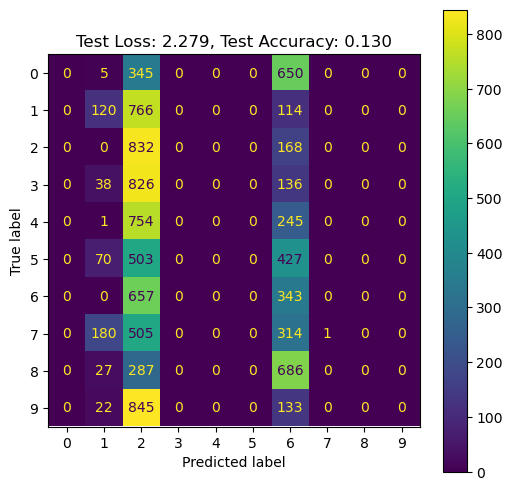

In [4]:
def average_model_weights(models):

    # Transpose the list of weights so we iterate layer-by-layer
    weight_lists = [m.get_weights() for m in models]

    avg_weights = []
    for weights_per_layer in zip(*weight_lists):
        # Convert to float32 for safety and efficiency
        layer_stack = [w.astype("float32") for w in weights_per_layer]
        avg_layer = sum(layer_stack) / len(layer_stack)
        avg_weights.append(avg_layer)

    return avg_weights

# get average weights
avg_weights = average_model_weights(models)

# Create a new model with the same architecture
model_soup = keras.models.clone_model(models[0])
model_soup.set_weights(avg_weights)

# could compile here if we wanted to do further training, but we're not going to
# worry about that here

# evaluate the model
eval_model(model_soup, None, x_test, y_test)

And, it sucks.

This was expected, and as outlined above there are some good reasons why this sucks.

## Experiment 2: Train some models, average them (but now use the same random seed)

We'll now repeat the above, but use the same random seed for each training run. This should keep the models more similar, and so our average should work a bit better.

In [5]:
models = []
histories = []
batch_size = init_batch_size
for i in range(n_models):
    model = build_model(random_seed = 42)
    if (i % 2) == 0:
        h, model = train_model(model, batch_size, keras.optimizers.Adam())
    else:
        h, model = train_model(model, batch_size, keras.optimizers.AdamW())
    batch_size = batch_size*2
    models.append(model)
    histories.append(h)
    
# quickly check performance of the models
eval_all_models(models, x_test, y_test)
# you could visualise the performance of one or more models too    
#eval_model(models[0], histories[0].history, x_test, y_test)

E0000 00:00:1768775576.247260     136 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fashion_mnist_cnn_model_1/spatial_dropout2d_9_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1768775656.540713     136 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fashion_mnist_cnn_model_1/spatial_dropout2d_12_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1768775725.161737     136 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fashion_mnist_cnn_model_1/spatial_dropout2d_15_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Model 0, Loss: 0.242; Acc: 0.9098001.3
Model 1, Loss: 0.244; Acc: 0.9113001.3
Model 2, Loss: 0.264; Acc: 0.9036001.3


Again, models seem ok.

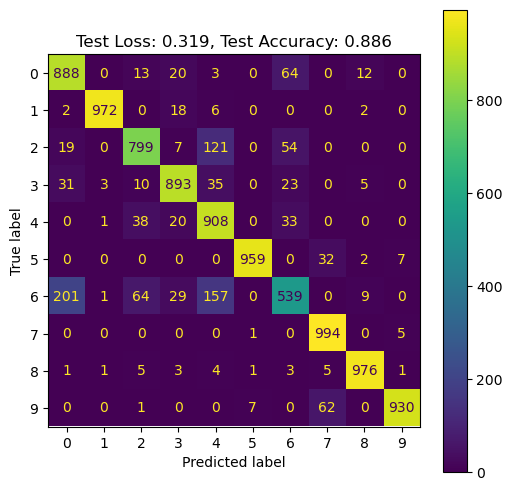

In [6]:
# get average weights
avg_weights = average_model_weights(models)

# Create a new model with the same architecture
model_soup = keras.models.clone_model(models[0])
model_soup.set_weights(avg_weights)

# could compile here if we wanted to do further training, but we're not going to
# worry about that here

# evaluate the model
eval_model(model_soup, None, x_test, y_test)

And our soup is better. 

We're still below our single model, but not by a huge amount. This small drop is not surprising as while we're now more likely to end up with similar weights for all models, the initialisation is still somewhat weak and so we're still likely to see a bit of variation in each of our models. Hence we end up with a solution that's ok, but is a bit below the individual models that make up the soup.

## Experiment 3: Fine Tuning Models

Now we'll do it (somewhat) properly and fine-tune some models. 

In [7]:
models = []
histories = []
batch_size = init_batch_size
for i in range(n_models):
    model = keras.models.load_model('../models/vgg_3stage_MNIST_small.keras')
    if (i % 2) == 0:
        h, model = train_model(model, batch_size, keras.optimizers.Adam(), from_logits=True)
    else:
        h, model = train_model(model, batch_size, keras.optimizers.AdamW(), from_logits=True)
    batch_size = batch_size*2
    models.append(model)
    histories.append(h)
    
# quickly check performance of the models
eval_all_models(models, x_test, y_test)
# you could visualise the performance of one or more models too
#eval_model(models[0], histories[0].history, x_test, y_test)

E0000 00:00:1768775786.988613     136 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/simple_vgg_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1768775858.979659     136 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/simple_vgg_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Model 0, Loss: 0.237; Acc: 0.9133001.3
Model 1, Loss: 0.243; Acc: 0.9127001.3
Model 2, Loss: 0.237; Acc: 0.9155001.3


Again, the individual models are all ok.

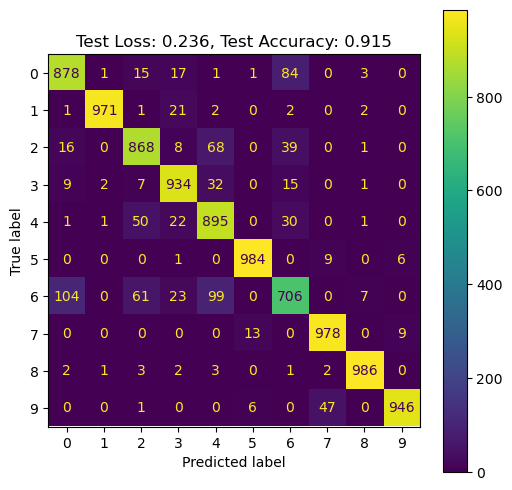

In [8]:
# get average weights
avg_weights = average_model_weights(models)

# Create a new model with the same architecture
model_soup = keras.models.clone_model(models[0])
model_soup.set_weights(avg_weights)

# could compile here if we wanted to do further training, but we're not going to
# worry about that here
# evaluate the model
eval_model(model_soup, None, x_test, y_test)

And our soup actually improves very slightly over the individual models, achieving a lower loss and identical accuracy.

The gain here is tiny, but if we wanted to scale this up we could consider:
* A bigger model, where the added complexity would benefit from the regularisation that the soup offers
* A bigger soup, with more variation in the training hyper-parameters
* A greedy soup, where rather than just take all models we take the best / most well-aligned subset and average them

All of these are beyond the scope of this example, but hopefully this gives some ideas for how these could work.